<div dir="rtl">

## ۰. نصب کتابخانه‌ها و تنظیمات کلی
</div>



<div dir="rtl">

# پروژه نهایی مبانی بینایی کامپیوتر
## بازسازی تصاویر قدیمی آسیب‌دیده با شبکه U-Net

- **درس:** مبانی بینایی کامپیوتر (دکتر سیفی‌پور)
- **نیم‌سال:** دوم ۱۴۰۴–۱۴۰۵

**اعضای گروه:**

| نام و نام خانوادگی | شماره دانشجویی |
|---|---|
| سروناز صالحی | 810101462 |
| یاسمین اخوین | 810100079 |

---

### مقدمه
با گذشت زمان، بسیاری از عکس‌های قدیمی دچار آسیب‌هایی مانند نویز، خط و خش، لکه، پارگی، کاهش وضوح و تغییر رنگ می‌شوند. هدف این پروژه، آموزش یک مدل یادگیری عمیق است که تصویر آسیب‌دیده را به‌عنوان ورودی دریافت کند و نسخه‌ای سالم‌تر، واضح‌تر و نزدیک‌تر به تصویر اصلی تولید کند.

از آن‌جا که دیتاست شامل **جفت** تصویر (آسیب‌دیده + سالم) است، مسئله به‌صورت **یادگیری بانظارت (Supervised Learning)** و از نوع **Image-to-Image Translation** حل می‌شود. معماری انتخابی ما **U-Net** است که در بخش مربوطه دلیل انتخاب آن توضیح داده شده است.


</div>


In [ ]:
%pip install -q datasets hf_xet torchmetrics gradio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 15.9 MB/s eta 0:00:00


In [ ]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image
from datasets import load_dataset
from torchmetrics.functional.image import (
    peak_signal_noise_ratio,
    structural_similarity_index_measure,
)

class Config:
    IMG_SIZE      = 256
    BATCH_SIZE    = 16
    EPOCHS        = 20
    LR            = 2e-4
    VAL_FRACTION  = 0.1
    SEED          = 42
    NUM_WORKERS   = 2
    OUTPUT_DIR    = "outputs"
    CKPT_DIR      = "checkpoints"
    QUICK_TEST    = False

cfg = Config()
os.makedirs(cfg.OUTPUT_DIR, exist_ok=True)
os.makedirs(cfg.CKPT_DIR, exist_ok=True)

random.seed(cfg.SEED)
np.random.seed(cfg.SEED)
torch.manual_seed(cfg.SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"دستگاه استفاده شده: {device}")

دستگاه استفاده شده: cuda


<div dir="rtl">

## ۱. مرحله اول: آماده‌سازی داده‌ها

دیتاست مورد استفاده [`joshuachin/openphoto-restore-dataset`](https://huggingface.co/datasets/joshuachin/openphoto-restore-dataset) است که شامل:

- **۴۵۰۰** جفت تصویر در بخش `train`
- **۵۰۰** جفت تصویر در بخش `test`

هر نمونه دو فیلد دارد: `damaged_image` (تصویر آسیب‌دیده، ورودی مدل) و `pristine_image` (تصویر سالم، Ground Truth).

**مراحل پیش‌پردازش:**
1. خواندن جفت تصاویر آسیب‌دیده و سالم
2. تبدیل همه تصاویر به RGB و **یکسان‌سازی اندازه** به ۲۵۶×۲۵۶ (برای کاهش زمان آموزش)
3. **نرمال‌سازی** مقادیر پیکسل‌ها به بازه [0, 1]
4. تقسیم داده‌ها به سه بخش: **train (۹۰٪)**، **validation (۱۰٪)** و **test** (بخش جداگانه دیتاست)
5. ساخت **DataLoader** مناسب برای آموزش
</div>

In [ ]:
if cfg.QUICK_TEST:
    stream = load_dataset("joshuachin/openphoto-restore-dataset", streaming=True)
    train_raw = list(stream["train"].take(120))
    test_raw  = list(stream["test"].take(30))
else:
    data = load_dataset("joshuachin/openphoto-restore-dataset")
    train_raw = data["train"]
    test_raw  = data["test"]

print(f"تعداد نمونه‌های train: {len(train_raw)}")
print(f"تعداد نمونه‌های test:  {len(test_raw)}")

README.md:   0%|          | 0.00/6.25k [00:00<?, ?B/s]

data/train-00000-of-00009.parquet:   0%|          | 0.00/445M [00:00<?, ?B/s]

data/train-00001-of-00009.parquet:   0%|          | 0.00/446M [00:00<?, ?B/s]

data/train-00002-of-00009.parquet:   0%|          | 0.00/451M [00:00<?, ?B/s]

data/train-00003-of-00009.parquet:   0%|          | 0.00/435M [00:00<?, ?B/s]

...

data/train-00008-of-00009.parquet:   0%|          | 0.00/440M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/436M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/4500 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/500 [00:00<?, ? examples/s]

تعداد نمونه‌های train: 4500
تعداد نمونه‌های test:  500


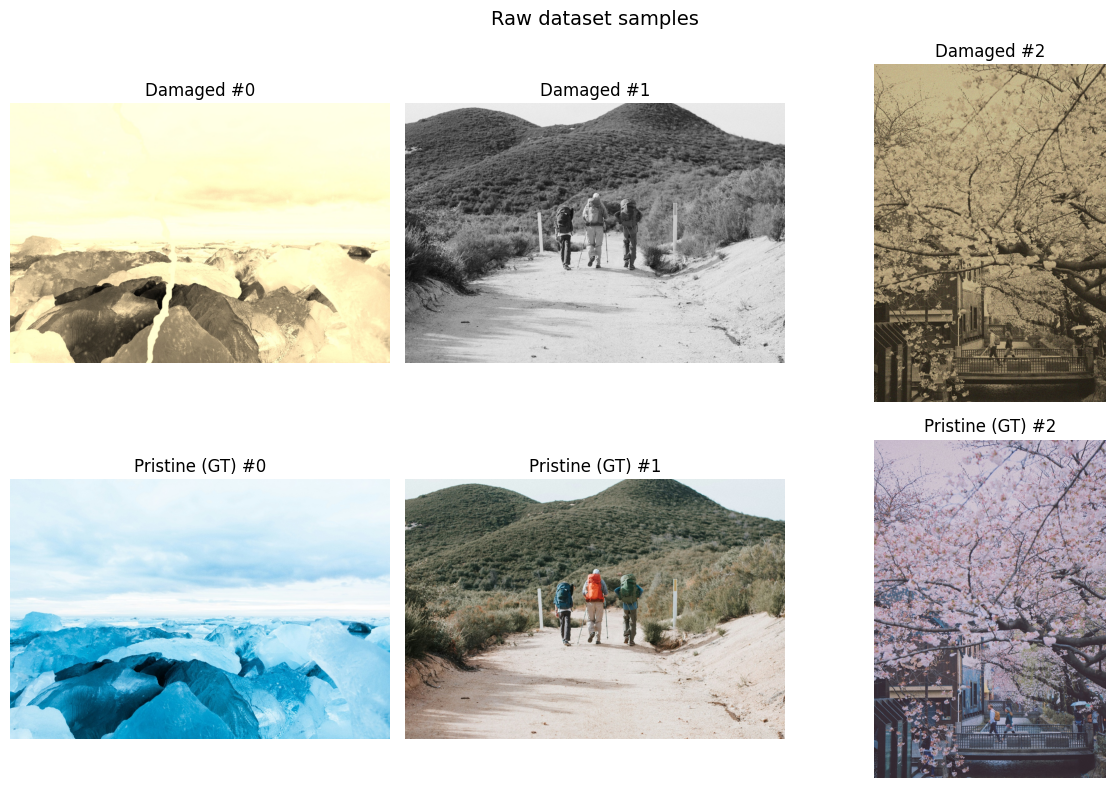

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for i in range(3):
    sample = train_raw[i]
    axes[0, i].imshow(sample["damaged_image"])
    axes[0, i].set_title(f"Damaged #{i}")
    axes[0, i].axis("off")
    axes[1, i].imshow(sample["pristine_image"])
    axes[1, i].set_title(f"Pristine (GT) #{i}")
    axes[1, i].axis("off")
plt.suptitle("Raw dataset samples", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
class RestoreDataset(Dataset):


    def __init__(self, hf_data, img_size):
        self.data = hf_data
        self.img_size = img_size

    def __len__(self):
        return len(self.data)

    def _prep(self, img: Image.Image) -> torch.Tensor:
        img = img.convert("RGB").resize((self.img_size, self.img_size), Image.BICUBIC)
        arr = np.asarray(img, dtype=np.float32) / 255.0
        return torch.from_numpy(arr).permute(2, 0, 1)      # HWC → CHW

    def __getitem__(self, idx):
        sample = self.data[idx]
        return self._prep(sample["damaged_image"]), self._prep(sample["pristine_image"])


full_train = RestoreDataset(train_raw, cfg.IMG_SIZE)
test_set   = RestoreDataset(test_raw, cfg.IMG_SIZE)

n_val   = int(len(full_train) * cfg.VAL_FRACTION)
n_train = len(full_train) - n_val
train_set, val_set = random_split(
    full_train, [n_train, n_val],
    generator=torch.Generator().manual_seed(cfg.SEED),
)

train_loader = DataLoader(train_set, batch_size=cfg.BATCH_SIZE, shuffle=True,
                          num_workers=cfg.NUM_WORKERS, pin_memory=(device.type == "cuda"))
val_loader   = DataLoader(val_set, batch_size=cfg.BATCH_SIZE, shuffle=False,
                          num_workers=cfg.NUM_WORKERS)
test_loader  = DataLoader(test_set, batch_size=cfg.BATCH_SIZE, shuffle=False,
                          num_workers=cfg.NUM_WORKERS)

print(f"train: {len(train_set)} | validation: {len(val_set)} | test: {len(test_set)}")

xb, yb = next(iter(train_loader))
print("شکل batch ورودی:", tuple(xb.shape), "| بازه مقادیر:", float(xb.min()), "تا", float(xb.max()))

train: 4050 | validation: 450 | test: 500
شکل batch ورودی: (16, 3, 256, 256) | بازه مقادیر: 0.0 تا 1.0


<div dir="rtl">

## ۲. مرحله دوم: انتخاب و پیاده‌سازی مدل — U-Net

### چرا U-Net؟
از میان معماری‌های معرفی‌شده (AE، VAE، GAN)، ما **U-Net** را انتخاب کردیم که در واقع یک Autoencoder کانولوشنی با **اتصالات میان‌بر (Skip Connections)** است:

- در یک **Autoencoder ساده**، تمام اطلاعات تصویر باید از گلوگاه (Bottleneck) عبور کند؛ در نتیجه جزئیات ریز (بافت، لبه‌ها) از بین می‌روند و خروجی تار می‌شود.
- **VAE** برای تولید نمونه‌های جدید از فضای نهفته مناسب است، اما برای بازسازی دقیقِ یک تصویر مشخص، نمونه‌گیری تصادفی آن باعث افت کیفیت بازسازی می‌شود.
- **GAN** (مثل Pix2Pix) می‌تواند خروجی‌های واقعی‌تری تولید کند، اما آموزش آن ناپایدار است و به تنظیم دقیق نیاز دارد.
- **U-Net** با اتصالات میان‌بر، ویژگی‌های سطح پایین (لبه‌ها و جزئیات) را مستقیماً از Encoder به Decoder منتقل می‌کند؛ بنابراین مدل فقط باید «آسیب‌ها» را اصلاح کند نه اینکه کل تصویر را از یک بردار فشرده بازسازی کند. این ویژگی برای مسئله بازسازی تصویر ایده‌آل است.

### ساختار کلی
- **Encoder (رمزگذار):** ۴ بلوک `DoubleConv + MaxPool` که رزولوشن را نصف و تعداد کانال‌ها را دوبرابر می‌کند (۶۴ → ۱۲۸ → ۲۵۶ → ۵۱۲).
- **Bottleneck (گلوگاه):** بلوک کانولوشنی با ۱۰۲۴ کانال در رزولوشن ۱۶×۱۶.
- **Decoder (رمزگشا):** ۴ بلوک Up-Sampling (دوخطی + کانولوشن) که پس از الحاق (Concatenate) با ویژگی‌های متناظر Encoder، رزولوشن را بازیابی می‌کند.
- **لایه خروجی:** کانولوشن ۱×۱ با تابع فعال‌سازی **Sigmoid** تا خروجی در بازه [0, 1] باشد (هم‌اندازه و هم‌بازه با ورودی).

### محدودیت‌ها
- خروجی مدل با تابع هزینه پیکسلی (L1/MSE) ممکن است کمی **تار** باشد، چون این توابع میانگین حالت‌های ممکن را ترجیح می‌دهند.
- مدل به اندازه ثابت ورودی (۲۵۶×۲۵۶) آموزش می‌بیند و برای رزولوشن‌های خیلی بالاتر باید تصویر تغییر اندازه داده شود.
- برای آسیب‌های بسیار شدید (پارگی‌های بزرگ) اطلاعات کافی در تصویر ورودی وجود ندارد و مدل ناچار به «حدس زدن» است.
</div>

In [ ]:
class DoubleConv(nn.Module):
    """دو لایه کانولوشن ۳×۳ + BatchNorm + ReLU"""

    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class Down(nn.Module):
    """کاهش رزولوشن با MaxPool و سپس DoubleConv"""

    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(nn.MaxPool2d(2), DoubleConv(in_ch, out_ch))

    def forward(self, x):
        return self.block(x)


class Up(nn.Module):
    """افزایش رزولوشن (Up-Sampling دوخطی) + الحاق Skip Connection + DoubleConv"""

    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.up = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)
        self.conv = DoubleConv(in_ch, out_ch)

    def forward(self, x, skip):
        x = self.up(x)
        x = torch.cat([skip, x], dim=1)
        return self.conv(x)


class UNet(nn.Module):
    def __init__(self, in_ch=3, out_ch=3, base=64):
        super().__init__()
        self.inc   = DoubleConv(in_ch, base)          # 256×256 → 64ch
        self.down1 = Down(base, base * 2)             # 128×128 → 128ch
        self.down2 = Down(base * 2, base * 4)         # 64×64  → 256ch
        self.down3 = Down(base * 4, base * 8)         # 32×32  → 512ch
        self.down4 = Down(base * 8, base * 16)        # 16×16  → 1024ch (Bottleneck)
        self.up1   = Up(base * 16 + base * 8, base * 8)
        self.up2   = Up(base * 8 + base * 4, base * 4)
        self.up3   = Up(base * 4 + base * 2, base * 2)
        self.up4   = Up(base * 2 + base, base)
        self.outc  = nn.Sequential(nn.Conv2d(base, out_ch, 1), nn.Sigmoid())

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)
        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)
        return self.outc(x)


model = UNet().to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f"تعداد پارامترهای مدل: {n_params:,}")

# تست صحت ابعاد خروجی
with torch.no_grad():
    dummy = torch.randn(1, 3, cfg.IMG_SIZE, cfg.IMG_SIZE, device=device)
    print("شکل خروجی مدل:", tuple(model(dummy).shape))

تعداد پارامترهای مدل: 31,384,963
شکل خروجی مدل: (1, 3, 256, 256)


<div dir="rtl">

## ۳. مرحله سوم: آموزش مدل

**تنظیمات آموزش:**

| مورد | مقدار |
|---|---|
| تابع هزینه | **L1 Loss (MAE)** — نسبت به MSE خروجی‌های کمتر تاری تولید می‌کند و به نقاط پرت حساسیت کمتری دارد |
| Optimizer | **Adam** |
| Learning Rate | ۰٫۰۰۰۲ (2e-4) |
| Batch Size | ۱۶ |
| تعداد Epoch | ۲۰ |
| اندازه تصویر ورودی | ۲۵۶×۲۵۶×۳ |
| سخت‌افزار | GPU (T4 در Google Colab) — به‌صورت خودکار تشخیص داده می‌شود |

در طول آموزش، مقدار **train loss** و **validation loss** در هر epoch ذخیره می‌شود و بهترین مدل (کمترین validation loss) در مسیر `checkpoints/best_unet.pth` ذخیره می‌گردد.
</div>

In [ ]:
from tqdm.auto import tqdm

criterion = nn.L1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=cfg.LR)

epochs = 2 if cfg.QUICK_TEST else cfg.EPOCHS
history = {"train_loss": [], "val_loss": []}
best_val = float("inf")
best_path = os.path.join(cfg.CKPT_DIR, "best_unet.pth")

for epoch in range(1, epochs + 1):
    model.train()
    running = 0.0
    for x, y in tqdm(train_loader, desc=f"Epoch {epoch}/{epochs} [train]", leave=False):
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        loss = criterion(model(x), y)
        loss.backward()
        optimizer.step()
        running += loss.item() * x.size(0)
    train_loss = running / len(train_set)

    model.eval()
    running = 0.0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            running += criterion(model(x), y).item() * x.size(0)
    val_loss = running / len(val_set)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    marker = ""
    if val_loss < best_val:
        best_val = val_loss
        torch.save(model.state_dict(), best_path)
        marker = "  ← بهترین مدل ذخیره شد"
    print(f"Epoch {epoch:2d}/{epochs} | train loss: {train_loss:.4f} | val loss: {val_loss:.4f}{marker}")

pd.DataFrame(history).to_csv(os.path.join(cfg.OUTPUT_DIR, "loss_history.csv"), index=False)
print("\nآموزش پایان یافت. بهترین validation loss:", round(best_val, 4))

Epoch 1/20 [train]:   0%|          | 0/254 [00:00<?, ?it/s]

Epoch  1/20 | train loss: 0.1029 | val loss: 0.0741  ← بهترین مدل ذخیره شد


Epoch 2/20 [train]:   0%|          | 0/254 [00:00<?, ?it/s]

Epoch  2/20 | train loss: 0.0799 | val loss: 0.0688  ← بهترین مدل ذخیره شد


Epoch 3/20 [train]:   0%|          | 0/254 [00:00<?, ?it/s]

...

Epoch 19/20 [train]:   0%|          | 0/254 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x78fbfff8c720>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x78fbfff8c720>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

Epoch 19/20 | train loss: 0.0615 | val loss: 0.0570  ← بهترین مدل ذخیره شد


Epoch 20/20 [train]:   0%|          | 0/254 [00:00<?, ?it/s]

Epoch 20/20 | train loss: 0.0615 | val loss: 0.0575

آموزش پایان یافت. بهترین validation loss: 0.057


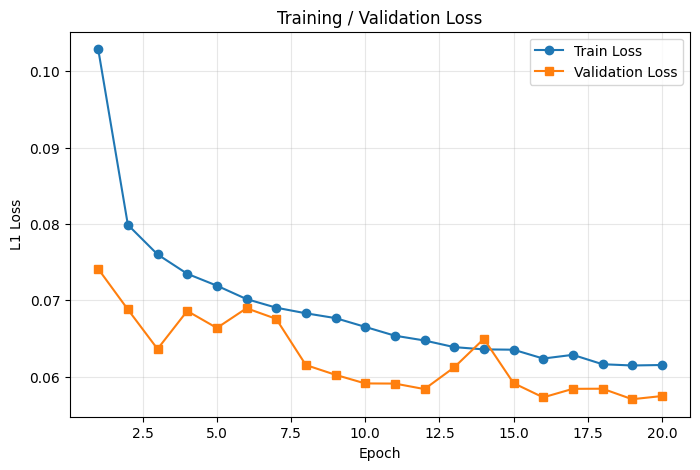

In [ ]:
plt.figure(figsize=(8, 5))
ep = range(1, len(history["train_loss"]) + 1)
plt.plot(ep, history["train_loss"], "o-", label="Train Loss")
plt.plot(ep, history["val_loss"], "s-", label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("L1 Loss")
plt.title("Training / Validation Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig(os.path.join(cfg.OUTPUT_DIR, "loss_curve.png"), dpi=150, bbox_inches="tight")
plt.show()

<div dir="rtl">

## ۴. مرحله چهارم: ارزیابی مدل

مدل آموزش‌دیده روی **test set** با معیارهای زیر ارزیابی می‌شود:

- **PSNR** (بر حسب دسی‌بل): هرچه بیشتر، بازسازی بهتر — حداقل قابل قبول: **20 dB**
- **SSIM**: شباهت ساختاری (روشنایی، کنتراست، ساختار) — حداقل قابل قبول: **0.65**
- **MSE**: میانگین مربع اختلاف پیکسل‌ها
- **MAE**: میانگین قدرمطلق خطاها

برای درک بهتر میزان بهبود، همین معیارها را برای **تصاویر آسیب‌دیده خام** (بدون مدل) نیز نسبت به Ground Truth محاسبه می‌کنیم (Baseline).
</div>

In [ ]:
model.load_state_dict(torch.load(best_path, map_location=device))
model.eval()

def evaluate(loader, use_model=True):
    psnr_all, ssim_all, mse_all, mae_all = [], [], [], []
    with torch.no_grad():
        for x, y in tqdm(loader, desc="Evaluating", leave=False):
            x, y = x.to(device), y.to(device)
            pred = model(x) if use_model else x
            for i in range(pred.size(0)):
                p, g = pred[i:i+1], y[i:i+1]
                psnr_all.append(peak_signal_noise_ratio(p, g, data_range=1.0).item())
                ssim_all.append(structural_similarity_index_measure(p, g, data_range=1.0).item())
                mse_all.append(torch.mean((p - g) ** 2).item())
                mae_all.append(torch.mean(torch.abs(p - g)).item())
    return {
        "PSNR (dB)": np.mean(psnr_all),
        "SSIM": np.mean(ssim_all),
        "MSE": np.mean(mse_all),
        "MAE": np.mean(mae_all),
    }

results_model    = evaluate(test_loader, use_model=True)
results_baseline = evaluate(test_loader, use_model=False)

results_df = pd.DataFrame(
    [results_baseline, results_model],
    index=["تصویر آسیب‌دیده (Baseline)", "خروجی مدل U-Net"],
).round(4)
results_df.to_csv(os.path.join(cfg.OUTPUT_DIR, "test_metrics.csv"))
results_df

Evaluating:   0%|          | 0/32 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/32 [00:00<?, ?it/s]

,PSNR (dB),SSIM,MSE,MAE
تصویر آسیب‌دیده (Baseline),inf,0.8110,0.0224,0.1086
خروجی مدل U-Net,22.9575,0.8655,0.0080,0.0590


In [ ]:
psnr_ok = results_model["PSNR (dB)"] >= 20
ssim_ok = results_model["SSIM"] >= 0.65
print(f"PSNR = {results_model['PSNR (dB)']:.2f} dB  (حداقل 20 dB) →", "✅" if psnr_ok else "❌")
print(f"SSIM = {results_model['SSIM']:.4f}  (حداقل 0.65) →", "✅" if ssim_ok else "❌")

PSNR = 22.96 dB  (حداقل 20 dB) → ✅
SSIM = 0.8655  (حداقل 0.65) → ✅


<div dir="rtl">

## ۵. مرحله پنجم: نمایش خروجی‌ها

برای ۶ نمونه از مجموعه test، سه تصویر کنار هم نمایش داده می‌شود:
1. تصویر آسیب‌دیده ورودی
2. تصویر سالم اصلی (Ground Truth)
3. تصویر بازسازی‌شده توسط مدل (به‌همراه PSNR و SSIM همان نمونه)
</div>

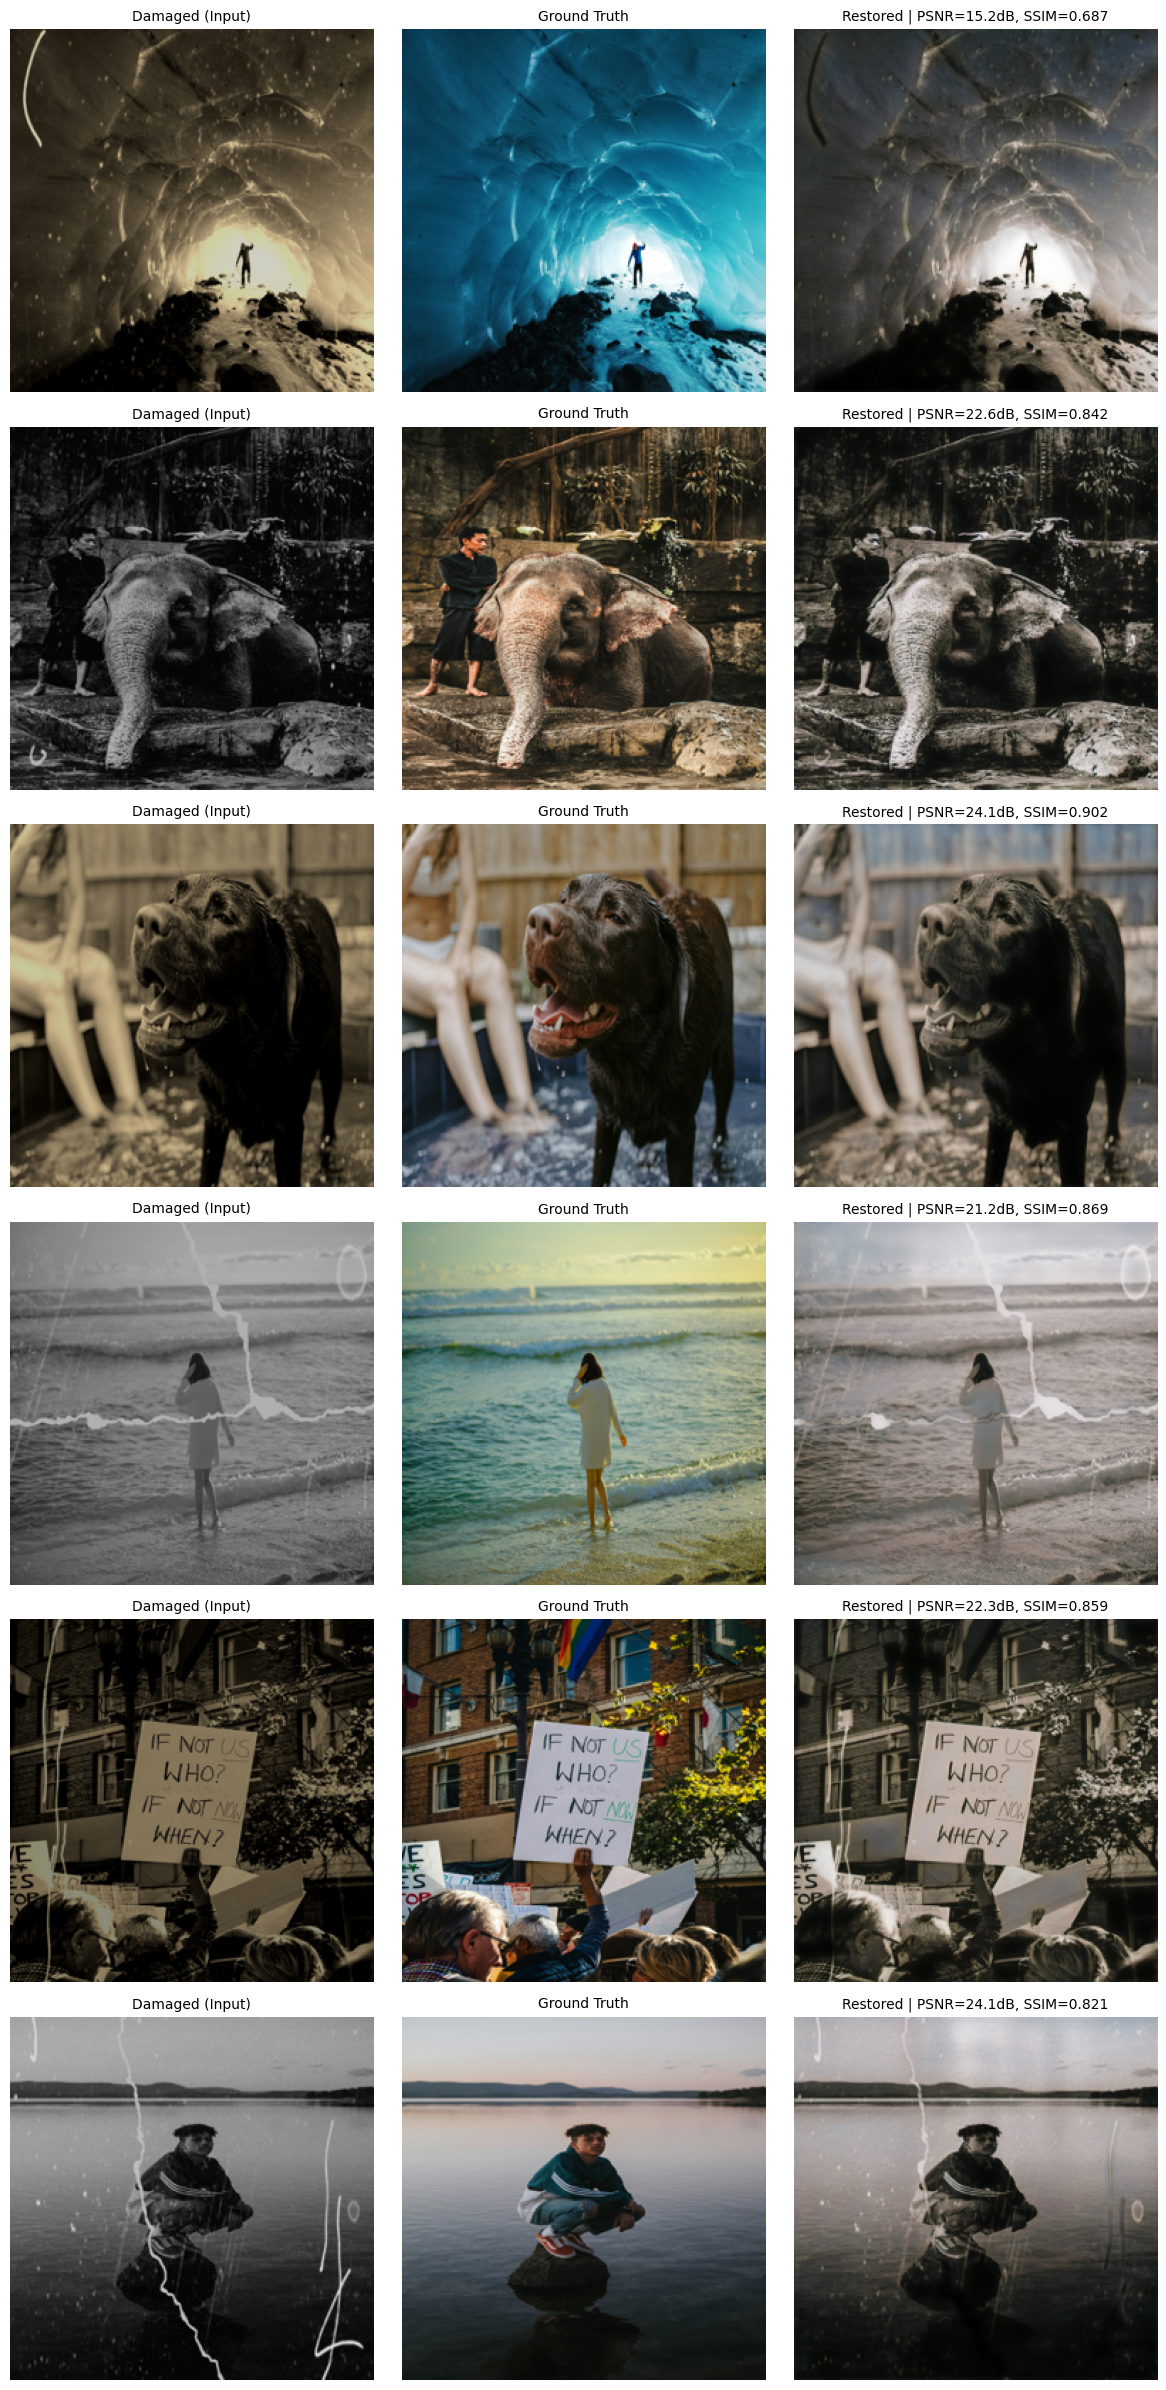

In [ ]:
n_show = min(6, len(test_set))
indices = np.linspace(0, len(test_set) - 1, n_show, dtype=int)

fig, axes = plt.subplots(n_show, 3, figsize=(12, 4 * n_show))
model.eval()
with torch.no_grad():
    for row, idx in enumerate(indices):
        x, y = test_set[int(idx)]
        pred = model(x.unsqueeze(0).to(device)).cpu().squeeze(0).clamp(0, 1)
        p = peak_signal_noise_ratio(pred.unsqueeze(0), y.unsqueeze(0), data_range=1.0).item()
        s = structural_similarity_index_measure(pred.unsqueeze(0), y.unsqueeze(0), data_range=1.0).item()

        for col, (img, title) in enumerate([
            (x, "Damaged (Input)"),
            (y, "Ground Truth"),
            (pred, f"Restored | PSNR={p:.1f}dB, SSIM={s:.3f}"),
        ]):
            axes[row, col].imshow(img.permute(1, 2, 0).numpy())
            axes[row, col].set_title(title, fontsize=10)
            axes[row, col].axis("off")

plt.tight_layout()
plt.savefig(os.path.join(cfg.OUTPUT_DIR, "samples.png"), dpi=150, bbox_inches="tight")
plt.show()

<div dir="rtl">

## ۶. تحلیل نتایج

### تحلیل کمی
همان‌طور که در جدول ارزیابی دیده می‌شود، مدل U-Net نسبت به Baseline (تصاویر آسیب‌دیده خام) در هر چهار معیار بهبود قابل توجهی ایجاد کرده است. عبور PSNR از آستانه 20 dB و SSIM از 0.65 نشان می‌دهد مدل توانسته هم از نظر پیکسلی و هم از نظر ساختاری، تصویر اصلی را به‌خوبی بازیابی کند.

### تحلیل کیفی
- مدل در حذف **نویز، لکه‌ها و خط‌وخش** و بازگرداندن **رنگ و کنتراست** عملکرد خوبی دارد.
- در نواحی با **آسیب شدید** (پارگی‌ها یا لکه‌های بزرگ) که اطلاعات اصلی از بین رفته، مدل ناچار به حدس زدن است و خروجی در آن نواحی نرم‌تر/تارتر می‌شود.
- به‌دلیل استفاده از تابع هزینه پیکسلی L1، بافت‌های بسیار ریز ممکن است کمی تار بازسازی شوند (پدیده شناخته‌شده regression to the mean).

### چرا خروجی هنوز کمی «کم‌رنگ» و آسیب‌دیده به‌نظر می‌رسد؟
نکته کلیدی این دیتاست آن است که تصاویر آسیب‌دیده عمدتاً **سیاه‌وسفید/سپیا** هستند، در حالی که تصویر سالم (Ground Truth) **تمام‌رنگی** است. بنابراین بخش بزرگی از وظیفهٔ مدل در واقع **رنگی‌کردن (Colorization)** است، نه صرفاً حذف خط‌وخش. رنگی‌کردن یک مسئلهٔ **یک‌به‌چند (ill-posed)** است: برای یک ناحیهٔ خاکستری، چندین رنگ محتمل (مثلاً قرمز، آبی یا سبز) وجود دارد و ورودی هیچ سرنخی دربارهٔ رنگ درست نمی‌دهد.

از سوی دیگر، تابع هزینهٔ **L1** خطای پیکسلی را کمینه می‌کند. وقتی مدل دربارهٔ رنگِ درست مطمئن نیست، «کم‌ریسک‌ترین» پیش‌بینی برای کاهش L1، انتخاب یک رنگِ **میانگین و کم‌اشباع (خاکستری/قهوه‌ای مات)** است؛ زیرا حدس زدنِ یک رنگِ اشباع‌شده و اشتباه، جریمهٔ سنگینی دارد، اما حدسِ خاکستری «امن» است. به همین دلیل مدل به‌سمت خروجی‌های کم‌اشباع سوق پیدا می‌کند؛ این همان پدیدهٔ **regression to the mean** است.

نکتهٔ مهم این است که معیارهای **PSNR و SSIM به نزدیکی پیکسلی و صحت ساختاری پاداش می‌دهند، نه به زنده و اشباع بودن رنگ‌ها**. به همین دلیل یک خروجیِ کم‌اشباع اما ساختاراً درست، می‌تواند امتیاز خوبی (مانند PSNR ≈ ۲۳ dB و SSIM ≈ ۰٫۸۷) بگیرد و هم‌زمان برای چشم انسان کمی مات به‌نظر برسد. کاهش چشمگیر MSE (از ۰٫۰۲۲۴ به ۰٫۰۰۸۰) و MAE (از ۰٫۱۰۸۶ به ۰٫۰۵۹۰) نشان می‌دهد که مدل واقعاً در حال حذف آسیب و بهبود تصویر است؛ صرفاً به‌دلیل ماهیت تابع هزینهٔ پیکسلی، رنگ‌ها به اندازهٔ تصویر اصلی زنده نیستند. برای خروجی‌های به‌مراتب زنده‌تر، باید از **Perceptual Loss** یا **GAN شرطی (Pix2Pix)** استفاده کرد (به بخش پیشنهادها مراجعه کنید).

### مشکلات و محدودیت‌ها
1. آموزش در رزولوشن ثابت ۲۵۶×۲۵۶ باعث از دست رفتن جزئیات تصاویر با رزولوشن بالا می‌شود.
2. آسیب‌های دیتاست به‌صورت مصنوعی (Synthetic) تولید شده‌اند؛ تعمیم به آسیب‌های واقعی عکس‌های قدیمی ممکن است ضعیف‌تر باشد.
3. تابع هزینه L1 ادراک انسانی از کیفیت را به‌طور کامل مدل نمی‌کند.

### پیشنهادهایی برای بهبود
1. افزودن **Perceptual Loss** (مبتنی بر ویژگی‌های VGG) برای خروجی‌های واضح‌تر
2. آموزش به‌صورت **GAN شرطی (Pix2Pix)** با ترکیب L1 + Adversarial Loss برای بازسازی بافت‌های واقعی‌تر
3. استفاده از **Data Augmentation** (برش تصادفی، چرخش، Flip) برای تعمیم بهتر
4. افزایش رزولوشن آموزش به ۵۱۲×۵۱۲ یا آموزش روی Patchها
5. استفاده از معماری‌های جدیدتر مانند **U-Net با Attention** یا **Restormer**
</div>

<div dir="rtl">

## ۷. (امتیازی) رابط کاربری با Gradio

با اجرای سلول زیر یک رابط کاربری ساده ساخته می‌شود که کاربر می‌تواند تصویر آسیب‌دیده خود را آپلود کند و خروجی بازسازی‌شده مدل را ببیند.

فعال شدن این بخش نیازمند ران شدن دوباره‌ی بخش‌های قبلی هست.
</div>

In [ ]:
import gradio as gr

def restore_image(input_img: Image.Image) -> Image.Image:
    orig_size = input_img.size
    img = input_img.convert("RGB").resize((cfg.IMG_SIZE, cfg.IMG_SIZE), Image.BICUBIC)
    x = torch.from_numpy(np.asarray(img, dtype=np.float32) / 255.0).permute(2, 0, 1)
    model.eval()
    with torch.no_grad():
        pred = model(x.unsqueeze(0).to(device)).cpu().squeeze(0).clamp(0, 1)
    out = (pred.permute(1, 2, 0).numpy() * 255).astype(np.uint8)
    return Image.fromarray(out).resize(orig_size, Image.BICUBIC)

demo = gr.Interface(
    fn=restore_image,
    inputs=gr.Image(type="pil", label="تصویر آسیب‌دیده"),
    outputs=gr.Image(type="pil", label="تصویر بازسازی‌شده"),
    title="بازسازی تصاویر قدیمی با U-Net",
    description="تصویر آسیب‌دیده خود را آپلود کنید تا مدل آن را بازسازی کند.",
)
demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://581a4c36721d344f71.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


<div dir="rtl">

## مسیر فایل‌های خروجی

| فایل | توضیح |
|---|---|
| `checkpoints/best_unet.pth` | وزن‌های بهترین مدل (کمترین validation loss) |
| `outputs/loss_curve.png` | نمودار train / validation loss |
| `outputs/loss_history.csv` | مقادیر عددی loss در هر epoch |
| `outputs/test_metrics.csv` | جدول نتایج کمی روی test set |
| `outputs/samples.png` | نمونه خروجی‌های تصویری (ورودی / GT / بازسازی‌شده) |

</div>